data.head():
data.info():
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 14999 entries, 0 to 14998
Data columns (total 10 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   satisfaction_level     14999 non-null  float64
 1   last_evaluation        14999 non-null  float64
 2   number_project         14999 non-null  int64  
 3   average_montly_hours   14999 non-null  int64  
 4   time_spend_company     14999 non-null  int64  
 5   Work_accident          14999 non-null  int64  
 6   left                   14999 non-null  int64  
 7   promotion_last_5years  14999 non-null  int64  
 8   Departments            14999 non-null  object 
 9   salary                 14999 non-null  object 
dtypes: float64(2), int64(6), object(2)
memory usage: 1.1+ MB
isnull() and sum():
data value counts():
data.head() for Salary:
x.head():
Accuracy value: 0.9843333333333333
Data Prediction:


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(


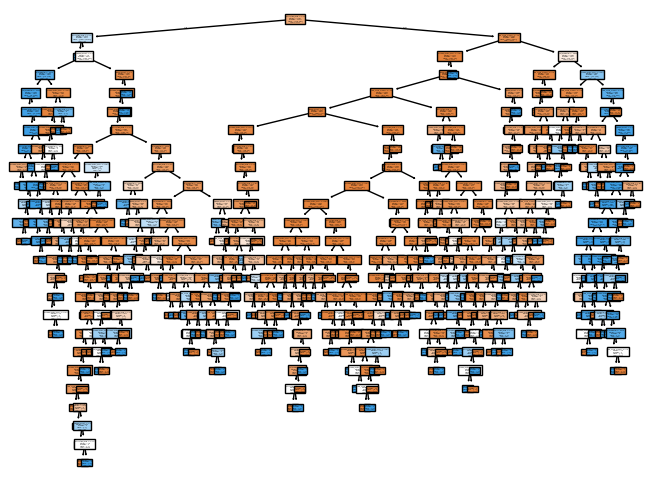

In [2]:
import pandas as pd
data=pd.read_csv("/content/drive/MyDrive/Employee.csv")

print("data.head():")
data.head()


print("data.info():")
data.info()


print("isnull() and sum():")
data.isnull().sum()


print("data value counts():")
data["left"].value_counts()


from sklearn.preprocessing import LabelEncoder
le=LabelEncoder()

print("data.head() for Salary:")
data["salary"]=le.fit_transform(data["salary"])
data.head()


print("x.head():")
x=data[["satisfaction_level","last_evaluation","number_project","average_montly_hours","time_spend_company","Work_accident","promotion_last_5years","salary"]]
x.head()


y=data["left"]


from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=100)
from sklearn.tree import DecisionTreeClassifier

dt=DecisionTreeClassifier(criterion="entropy")
dt.fit(x_train,y_train)
y_pred=dt.predict(x_test)


from sklearn import metrics
accuracy=metrics.accuracy_score(y_test,y_pred)
print("Accuracy value:", accuracy)


print("Data Prediction:")
dt.predict([[0.5,0.8,9,260,6,0,1,2]])


from sklearn.tree import plot_tree
import matplotlib.pyplot as plt


plt.figure(figsize=(8,6))
plot_tree(dt, feature_names=x.columns, class_names=['salary', 'left'], filled=True)
plt.show()